# Kaggle House Prices Prediction Model: Main Notebook
This notebook conforms to the "House Prices - Advanced Regression" challenge on Kaggle ([link here](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)). Here, you can find all the code for loading the data, setting up the model, and the various experimentations and attempts I've made to train a functional model.

The notebook is divided into sections based on the stage of model construction. Some code cells are based loosely off of various tutorials from Kaggle as a foundation. Once I'm done building the foundation off of the Kaggle tutorials, I'll go back and make tweaks to improve the peformance.

*Competition goal*: It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable. Submissions are evaluated on Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price.

## Load the data and import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
import xgboost as xgb # in case we decide to build an XGBoost model (recommended)

# load the dataset from the CSV file
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()
test.head()

# verify the shapes of the datasets before modification
print("Train shape: {}".format(train.shape)) # should be (1460, 81)
print("Test shape: {}".format(test.shape)) # should be (1459, 80)

# save the ID column
train_ID = train['Id']
test_ID = test['Id']

# drop the ID column as it's unnecessary for the training process
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

# verify the shapes of the datasets after dropping the ID column
print("Train shape after dropping ID feature: {}" .format(train.shape)) # should be (1460, 80)
print("Test shape after dropping ID feature: {}" .format(test.shape)) # should be (1459, 79)

Train shape: (1460, 81)
Test shape: (1459, 80)
Train shape after dropping ID feature: (1460, 80)
Test shape after dropping ID feature: (1459, 79)


## Plot and analyze the data

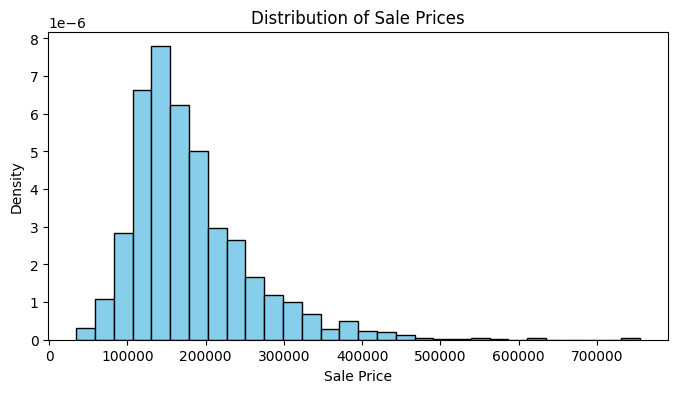

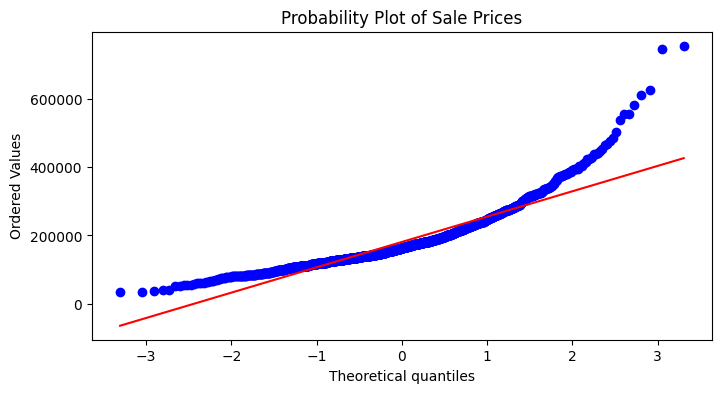

Skewness: 1.882876
Kurtosis: 6.536282


In [2]:
# get a description of the sale prices
from scipy import stats

train['SalePrice'].describe()

# create a distribution plot of the sale prices
plt.figure(figsize=(8, 4))
plt.hist(train['SalePrice'], bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.show()

# create a probability plot of the sale prices
plt.figure(figsize=(8, 4))
stats.probplot(train['SalePrice'], dist="norm", plot=plt)
plt.title("Probability Plot of Sale Prices")
plt.show()

# get the skewness and kurtosis of the sale prices
print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

# for this dataset, the skewness value is slightly above the normal, which means our data
# is a little bit skewed to the right in terms of tail length. The kurtosis is also above the normal,
# which indicates a higher possibility of extreme outliers.

## Discover patterns and correlations with the feature data
There are 80 features, so we're going to have to do some serious correlation analysis to figure out which features are the most important.

Feature counts: 43 + 37 = 80


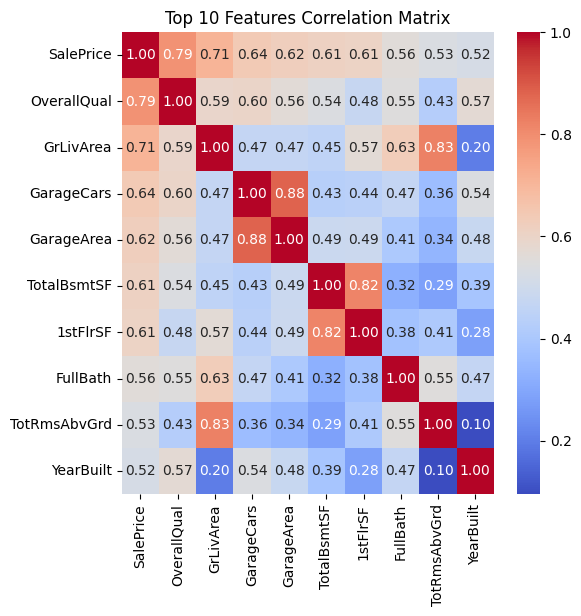

In [3]:
import seaborn as sns

# get feature counts
categorical = len(train.select_dtypes(include=['object']).columns) # should be 43
numerical = len(train.select_dtypes(exclude=['object']).columns) # should be 37 (including the target variable 'SalePrice')
print("Feature counts:", categorical, "+", numerical, "=", categorical + numerical)

# get full correlation matrix
corr_matrix = train.corr(numeric_only=True)
top_features = corr_matrix['SalePrice'].abs().nlargest(10).index # get the top 10 features related to SalePrice
top_corr_matrix = train[top_features].corr()

# create the heatmap with seaborn (you can do this with just Matplotlib too, but it's much harder)
plt.figure(figsize=(6, 6))
sns.heatmap(top_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title('Top 10 Features Correlation Matrix')
plt.show()


Text(0.5, 1.0, 'Overall Quality vs Sale Price')

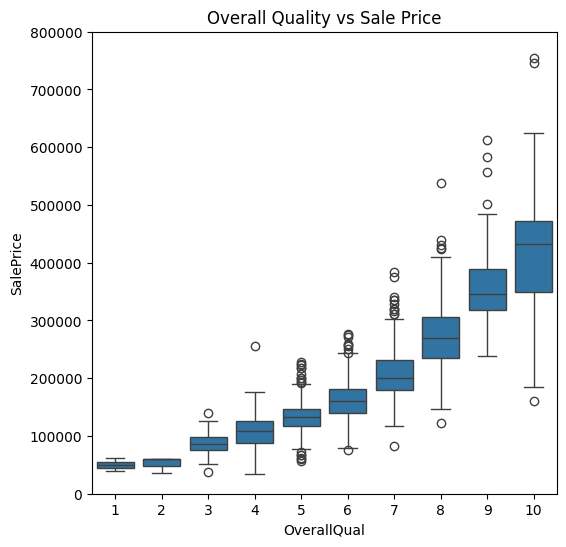

In [4]:
# visualize relations between overall quality and sale price (in box plot format)
var = 'OverallQual'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x=var, y='SalePrice', data=data)
fig.axis(ymin=0, ymax=800000)
plt.title('Overall Quality vs Sale Price')

Text(0.5, 1.0, 'Living Area vs Sale Price')

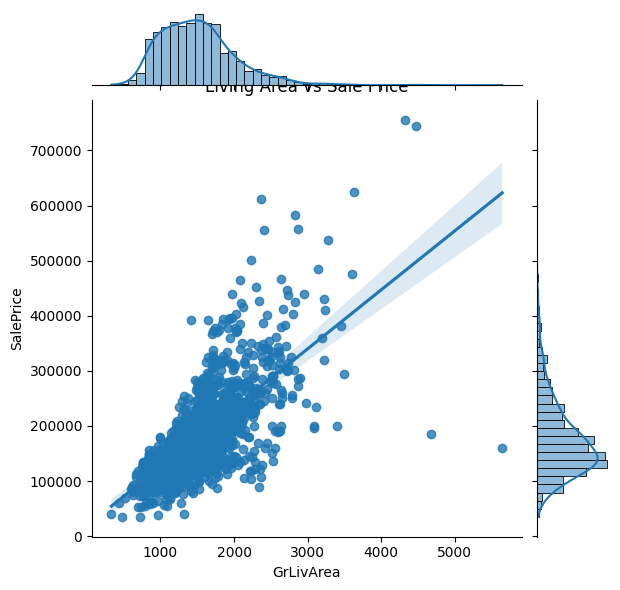

In [5]:
# visualize relations between living area and sale price (with scatter plot)
sns.jointplot(x=train['GrLivArea'], y=train['SalePrice'], kind='reg')
plt.title('Living Area vs Sale Price')

(1458, 80)


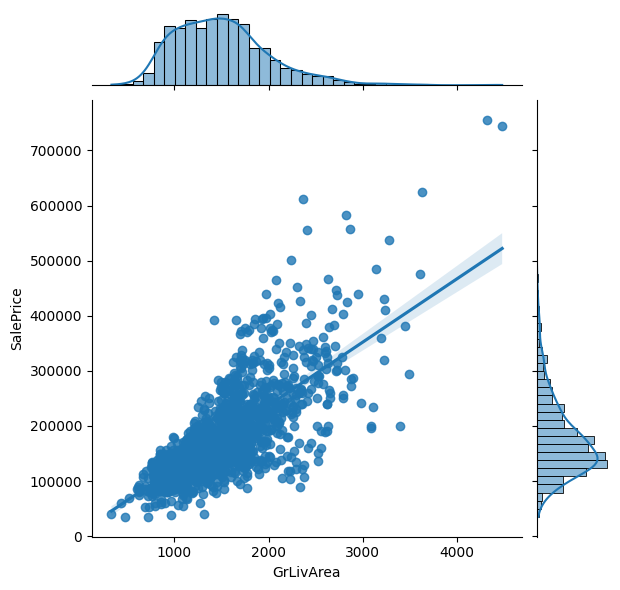

In [6]:
# drop the outliers in the plot (for example, the two data points in the bottom right)
# this drops all listings with sqft more than 4000 and price less than 300000 (in this case, only 2 'annoying' plots)

train = train.drop(train[(train['GrLivArea']>4000) 
                         & (train['SalePrice']<300000)].index).reset_index(drop=True)
print(train.shape)

sns.jointplot(x=train['GrLivArea'], y=train['SalePrice'], kind='reg')

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

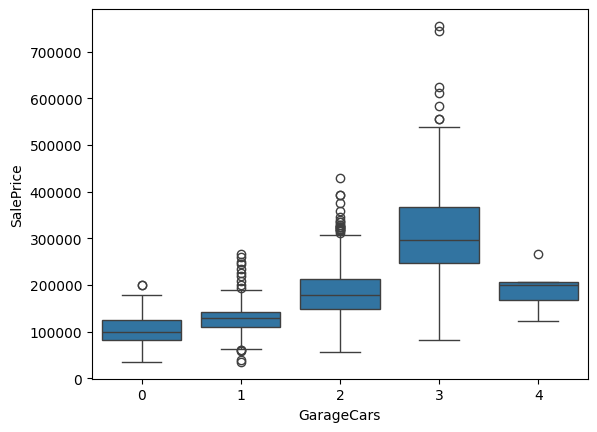

In [7]:
# visualize Garage Area vs Sale Price and do the same outlier removal there
sns.boxplot(x=train['GarageCars'], y=train['SalePrice'])

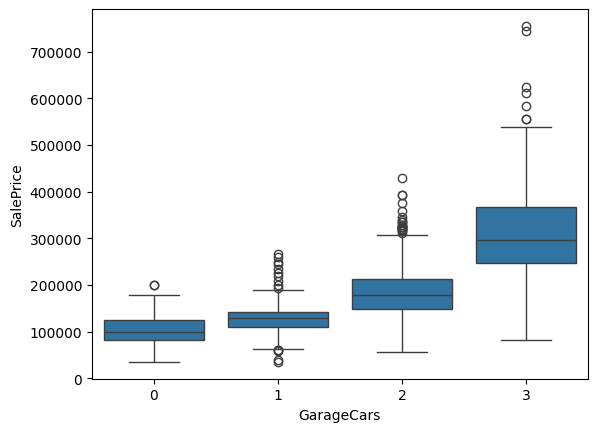

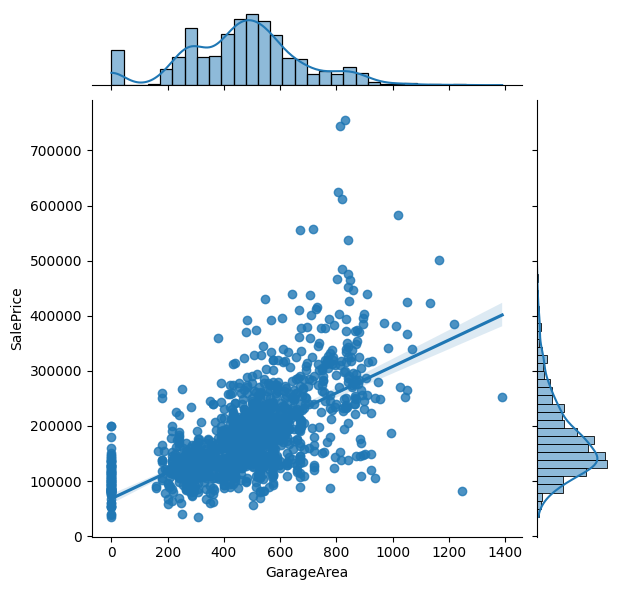

In [8]:
# may choose not to drop this because it might be useful for training anyway
# remove outliers in the GarageCars set (why do 4-car garages result in less sale price?)
train = train.drop(train[(train['GarageCars']>3) & (train['SalePrice']<300000)].index).reset_index(drop=True)
sns.boxplot(x=train['GarageCars'], y=train['SalePrice'])
sns.jointplot(x=train['GarageArea'], y=train['SalePrice'], kind='reg') # get plot of garage area and sale price

Pearson r score: 0.64


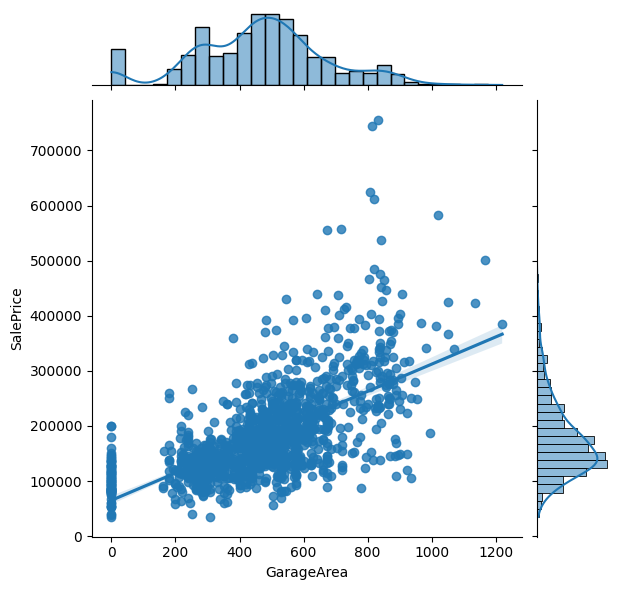

In [9]:
import scipy.stats as stats

# remove outliers in the above GarageArea plot
train = train.drop(train[(train['GarageArea']>1000) 
                         & (train['SalePrice']<300000)].index).reset_index(drop=True)
sns.jointplot(x=train['GarageArea'], y=train['SalePrice'], kind='reg')
r, p = stats.pearsonr(train['GarageArea'], train['SalePrice'])
print("Pearson r score: {:.2f}".format(r))

Text(0.5, 1.0, 'Year Built vs Sale Price')

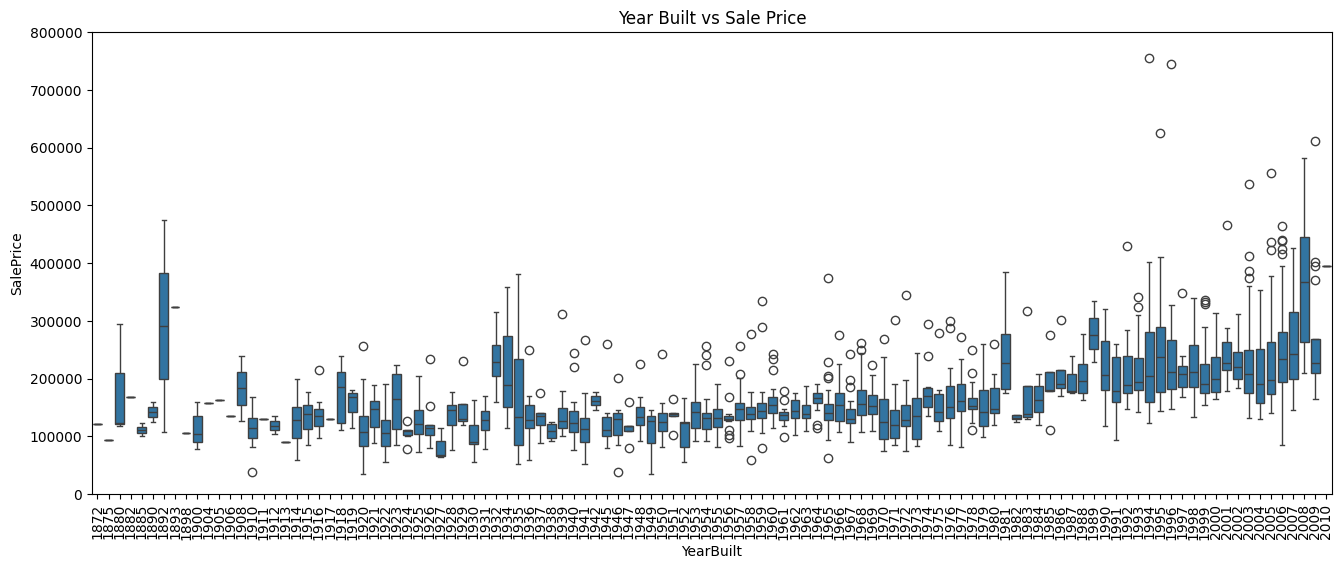

In [10]:
# visualize the relation between the year built and sale price (with box plot)
# we aren't going to do anything with this data here, as we can't be sure of the exact factors involved
var = 'YearBuilt'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 6))
fig = sns.boxplot(x=var, y='SalePrice', data=data)
fig.axis(ymin=0, ymax=800000)
plt.xticks(rotation=90)
plt.title("Year Built vs Sale Price")

# Clean Data and Impute Missing Values

In [11]:
# combine the datasets to check for missing values
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train.SalePrice.values
all_data = pd.concat((train, test), axis=0)
all_data.drop(['SalePrice'], axis=1, inplace=True)
print("Train data size: {}".format(train.shape))
print("Test data size: {}".format(test.shape))
print("Combined dataset size is: {}".format(all_data.shape))

Train data size: (1448, 80)
Test data size: (1459, 79)
Combined dataset size is: (2907, 79)


              Missing Ratio
PoolQC            99.690402
MiscFeature       96.422429
Alley             93.223254
Fence             80.392157
MasVnrType        60.543516
FireplaceQu       48.710010
LotFrontage       16.683867
GarageQual         5.469556
GarageYrBlt        5.469556
GarageCond         5.469556
GarageFinish       5.469556
GarageType         5.400757
BsmtExposure       2.820777
BsmtCond           2.820777
BsmtQual           2.786378
BsmtFinType2       2.751978
BsmtFinType1       2.717578
MasVnrArea         0.791194
MSZoning           0.137599
BsmtFullBath       0.068799
Functional         0.068799
BsmtHalfBath       0.068799
Utilities          0.068799
BsmtFinSF1         0.034400
Exterior2nd        0.034400
Exterior1st        0.034400
Electrical         0.034400
TotalBsmtSF        0.034400
BsmtUnfSF          0.034400
BsmtFinSF2         0.034400


Text(0.5, 1.0, 'Percent of Missing Data by Feature')

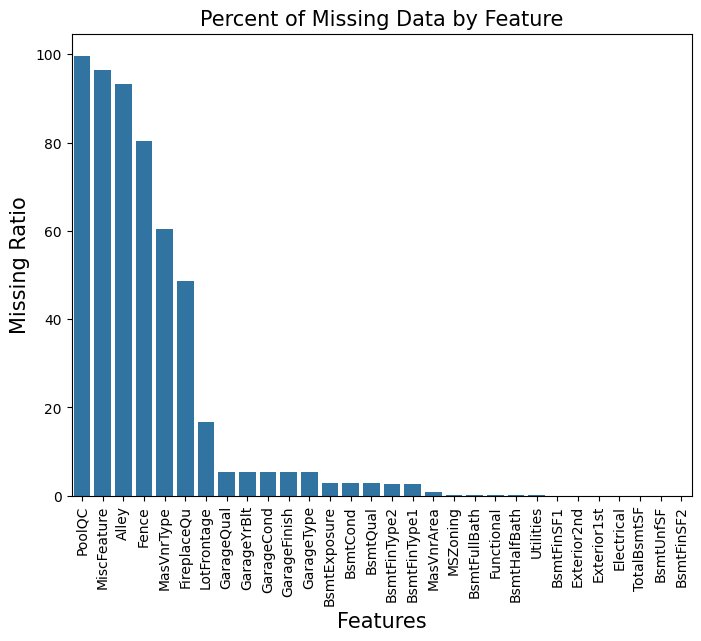

In [12]:
# find missing ratio of dataset (missing values / total values)
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({"Missing Ratio" :all_data_na})
print(missing_data)

# get a plot of the percent missing data by feature
f, ax = plt.subplots(figsize=(8,6))
plt.xticks(rotation='vertical')
sns.barplot(x=all_data_na.index, y=all_data_na)
plt.xlabel("Features", fontsize=15)
plt.ylabel("Missing Ratio", fontsize=15)
plt.title("Percent of Missing Data by Feature", fontsize=15)

# as you can see, the pool quality, alley access, and fence condition features have lots of missing values.
# however, this is not a cause for alarm because a missing value ('NA') in this case simply means that the house
# has no pool, no alley access, no fence, etc.

In [13]:
# impute missing values
all_data["PoolQC"] = all_data["PoolQC"].fillna("None") # e.g., no pool
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("None")
all_data["Alley"] = all_data["Alley"].fillna("None")
all_data["Fence"] = all_data["Fence"].fillna("None")
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("None")
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median())) # imputes the median lot size in the neighborhood
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    all_data[col] = all_data[col].fillna('None')
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    all_data[col] = all_data[col].fillna(0)
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_data[col] = all_data[col].fillna('None')
all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")
all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(0)
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0]) # for this and others involving MODE, we're substituting in the most common value
#all_data = all_data.drop(['Utilities'], axis=1)
all_data["Functional"] = all_data["Functional"].fillna("Typ")
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")

# check for any remaining missing values
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({"Missing Ratio" :all_data_na})
print(missing_data)

           Missing Ratio
Utilities       0.068799


# Feature Engineering
Here, we'll encode the labels for all categorical features (such as FireplaceQuality, BasementQuality, etc.) and fix issues of skewness in the data.

In [ ]:
from sklearn.preprocessing import LabelEncoder

all_data['MSSubClass'].describe()

# the MSSubClass feature (and others) are actually categorical (different types/conditions of homes), not numerical
# convert these into categorical variables
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)
all_data['OverallCond'] = all_data['OverallCond'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

# encode labels for all categorical features
labels = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
          'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence',
          'BsmtExposure', 'GarageFinish', 'LandSlope','LotShape', 'PoolQC', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 'YrSold', 'MoSold')
for label in labels:
    le = LabelEncoder()
    le.fit(list(all_data[label].values))
    all_data[label] = le.transform(list(all_data[label].values))

# add a Total Square Feet feature since the data doesn't have that (kind of crazy)
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# check shape
print(all_data.shape) # should be (2907, 80)


(2907, 80)


<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\car-m\AppData\Local\Temp\ipykernel_27128\457465216.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')


mu = 2.57 and sigma = 0.03


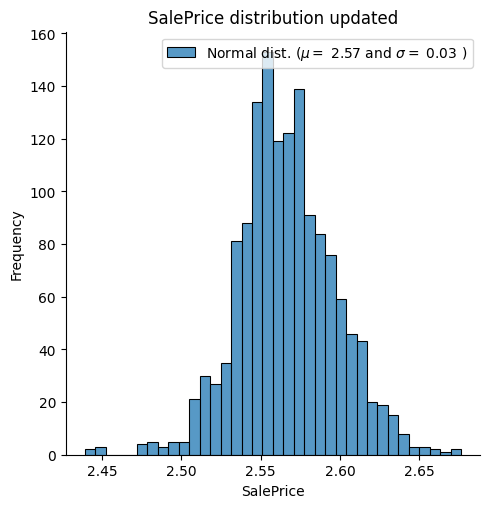

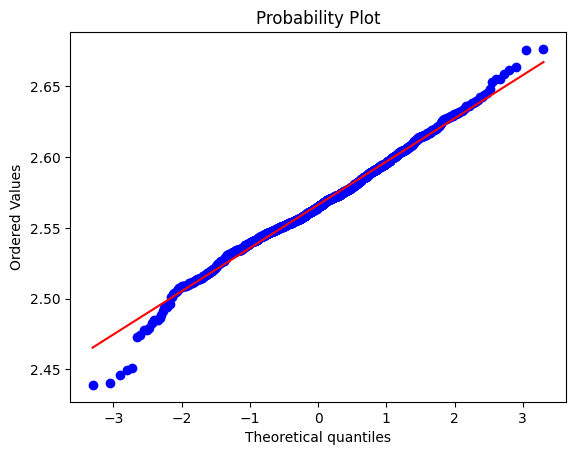

Skewness: -0.000996
Kurtosis: 0.899427


In [ ]:
# fix skewed features and hopefully improve kurtosis/skewness using the log1p function
train['SalePrice'] = np.log1p(train['SalePrice'])
sns.displot(train['SalePrice'], kind="hist")

# get the mu and sigma (mean and standard distribution) values of the data
(mu, sigma) = stats.norm.fit(train['SalePrice'])
print("mu = {:.2f} and sigma = {:.2f}".format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution updated')

fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

# get the skewness and kurtosis of the data
y_train = train.SalePrice.values
print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

# we find that both the skewness and kurtosis values are much better (they are very close to 0)

In [21]:
from scipy.special import boxcox1p

# Check and correct for skewness in numerical features
numerical_features = all_data.dtypes[all_data.dtypes != "object"].index
skewed_features = all_data[numerical_features].apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skewed Features': skewed_features})
skewness.head()

skewness = skewness[abs(skewness) > 0.75]
skewed_features = skewness.index
lam = 0.15 # lambda value for the box cox transofmration (range typically -1 to 1)
for feature in skewed_features:
    all_data[feature] = boxcox1p(all_data[feature], lam)
    all_data[feature] += 1 # add 1 to all features to avoid issues with log(0) or negative values

all_data = pd.get_dummies(all_data) # one-hot encode the entire dataset for training
print(all_data.shape)

# prepare the final train and test datasets
train = all_data[:ntrain]
test = all_data[ntrain:]

(2907, 224)


# Building the Model and Making Predictions